In [2]:
from pathlib import Path
from typing import Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates
import itertools

os.chdir("..")
from src.config import FIGURES_DIR, INTERIM_DATA_DIR

df = pd.read_csv(INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv")
df["Prescription Date"] = pd.to_datetime(df["Prescription Date"], format="%Y%m%d", errors="coerce")
df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

2025-08-28 14:27:53.092 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: D:\Research\Project_COPD\COPD
C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_73360\1892021385.py:13: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv")


In [3]:
def plot_patient_variables_grid(
    dfx: pd.DataFrame,
    patient_id: int,
    out_dir: Path = Path(FIGURES_DIR / "pft_plots_all_variants"),
    plot_variable_order: List[str] = None,
    wanted_measure_indexes: List[str] = None,
    measure_index_colors: Dict[str, str] = None,
    marker: str = "o",
    linewidth: float = 1.6,
    plot_anomaly: bool = True,
    *,
    title_suffix: str = "",
) -> None:
    """
    Create one figure with vertical subplots (one per Variable).
    - Plots selected Measurements over time (per subplot).
    - Uses full YYYY-MM-DD dates on x-axis; only bottom subplot has x-label.
    - Overlays anomaly markers as hollow squares (no text labels).
    - Adds measurement legend (single row) and stacked anomaly legend lines.

    Expects anomaly columns if available:
      'Anomaly_Missing', 'Anomaly_Range', 'Outlier_MAD', 'Outlier_Jump'
    The plot renders fine even if they are absent.
    """
    import itertools
    import matplotlib.dates as mdates
    from matplotlib.lines import Line2D

    wanted_measure_indexes = ['FEV1', 'FVC']

    if dfx.empty:
        return

    # ---- constants / basic prep ----
    DATE_COL  = "Prescription Date"
    VALUE_COL = "Result Numerical Value"
    VAR_COL   = "Variable"
    MEAS_COL  = "Measurement"

    dfx = dfx.copy()
    dfx[DATE_COL] = pd.to_datetime(dfx[DATE_COL], errors="coerce")
    dfx = dfx.sort_values(DATE_COL)

    if plot_variable_order is None:
        plot_variable_order = ["Meas", "%Pred", "%Chg.", "Post_Meas", "Post_%Pred", "Post_%Chg"]
    if wanted_measure_indexes is None:
        wanted_measure_indexes = sorted(dfx[MEAS_COL].dropna().unique().tolist())
    if measure_index_colors is None:
        base = ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
        measure_index_colors = {mi: c for mi, c in zip(wanted_measure_indexes, itertools.cycle(base))}
    # Define marker mapping per Test
    MARKERS_BY_TEST = {"PFT": ".", "BD": "1", "COD": "^", None: "|"}
    MARKER_COLORS_BY_TEST = {"PFT": "red", "BD": "black", "COD": "green", None: "blue"}

    # anomaly colors (distinct from typical Matplotlib defaults)
    ANOM_COLORS = {
        "Missing": "#FFB300",  # amber
        "Range":   "#8B0000",  # dark red
        "MAD":     "#000000",  # black
        "Jump":    "#00BFA6",  # teal
    }
    have_anom_cols = all(
        col in dfx.columns
        for col in ["Anomaly_Missing", "Anomaly_Range", "Outlier_MAD", "Outlier_Jump"]
    )

    # ---- figure & axes ----
    nrows = len(plot_variable_order)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=((16*2.3*nrows) / 9, 2.3*nrows), sharex=False)
    if nrows == 1:
        axes = [axes]

    handles_all, labels_all = [], []

    # ---- plotting per variable ----
    for ax, var in zip(axes, plot_variable_order):
        dft_var = dfx[dfx[VAR_COL] == var]
        ax.set_ylabel(var)
        ax.grid(True, linestyle="--", alpha=0.3)

        any_line = False
        for mi in wanted_measure_indexes:
            dft_sub  = dft_var[dft_var[MEAS_COL] == mi]
            if dft_sub.empty:
                continue

            # group by Test so each subgroup has its own marker
            for test_val, dft in dft_sub.groupby("Test"):
                h, = ax.plot(
                    dft[DATE_COL],
                    dft[VALUE_COL],
                    marker=MARKERS_BY_TEST.get(test_val, "|"),
                    markerfacecolor=MARKER_COLORS_BY_TEST.get(test_val, "blue"),
                    markeredgecolor=MARKER_COLORS_BY_TEST.get(test_val, "blue"),
                    linewidth=linewidth,
                    color=measure_index_colors.get(mi, "black"),
                    label=f"{test_val}-{mi}", zorder=2,
                )
                any_line = True
                if not any(lbl.get_label() == f"{test_val}-{mi}" for lbl in handles_all):
                    handles_all.append(h)
                    labels_all.append(f"{test_val}-{mi}")

                # anomaly overlays (squares) — only if anomaly cols exist
                if plot_anomaly and have_anom_cols:
                    anom_specs = [
                        ("MAD",     "Outlier_MAD"),
                        ("Jump",    "Outlier_Jump"),
                        ("Range",   "Anomaly_Range"),
                        ("Missing", "Anomaly_Missing"),
                    ]
                    for key, col in anom_specs:
                        if col in dft.columns and dft[col].any():
                            bad = dft[dft[col]]
                            ax.scatter(
                                bad[DATE_COL], bad[VALUE_COL],
                                s=80, marker="s",
                                facecolors="none", edgecolors=ANOM_COLORS[key],
                                linewidths=1.8, zorder=4
                            )

        if not any_line:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, alpha=0.6)

        # x-axis as full date per subplot
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        for tick in ax.get_xticklabels():
            tick.set_rotation(30)
            tick.set_ha("right")

    # x-label only on bottom subplot
    axes[-1].set_xlabel("Prescription Date")

    # title (with optional suffix)
    fig.suptitle(
        f"Patient {patient_id} — All Variables{(' — ' + title_suffix) if title_suffix else ''}",
        y=0.995, fontsize=14
    )

    # -------- LEGENDS (measurement row, then one anomaly per line) --------
    # 1) Measurement legend: single row
    if handles_all:
        fig.legend(
            handles_all, labels_all,
            loc="lower center", bbox_to_anchor=(0.5, 0.08),
            ncol=len(labels_all), fontsize=9, frameon=False,
            handlelength=2.0, handletextpad=0.6, columnspacing=1.2
        )

    # 2) One line per anomaly (stacked)
    anom_specs = [
        ("Missing Value: Value is zero.", ANOM_COLORS["Missing"]),
        ("Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; FEV1/FVC 0.2-1.2; %Pred 0-200.", ANOM_COLORS["Range"]),
        ("MAD: |robust_z| > z_thresh (3.5)", ANOM_COLORS["MAD"]),
        ("Jump: Δ/month > thresholds (FEV1 0.30, FVC 0.40, DLCO 3.0, FEV1/FVC 0.08, DLCO/VA 0.60).", ANOM_COLORS["Jump"]),
    ]
    y0, dy = 0.07, 0.01   # starting y and spacing between lines
    for i, (lab, col) in enumerate(anom_specs):
        h = Line2D([0],[0], marker='s', linestyle='None', markersize=8,
                   markerfacecolor='none', markeredgecolor=col, label=lab)
        fig.legend(
            [h], [lab],
            loc="lower center", bbox_to_anchor=(0.5, y0 - i*dy),
            ncol=1, fontsize=9, frameon=False, handlelength=1.2
        )

    # room for 1 (measurements) + 4 (anomalies) lines
    fig.subplots_adjust(bottom=0.16, top=0.95, hspace=0.5)

    # ---- save ----
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_name = f"patient_{patient_id}_variables_grid.png"
    fig.savefig(out_dir / out_name, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [4]:
patient_ids = [886482, 1207865, 1452945, 611957, 965594, 5665, 7429, 29903]
pid = 5 #611957
dfx = df[df["Patient Number"] == pid].copy()

In [5]:
dc=['Patient Number', 'Prescription Date',  'Test', 'Measurement', 'Variable', 'Result Numerical Value']
dfx["Prescription Date"] = pd.to_datetime(dfx["Prescription Date"], errors="coerce")
dfx = dfx.sort_values(
    by=["Prescription Date", "Measurement", "Variable"]
)[dc].reset_index(drop=True)
dfx=dfx[dc]
dfx

,Patient Number,Prescription Date,Test,Measurement,Variable,Result Numerical Value
0,5,2020-04-23,COD,DLCO,%Pred,63.00
1,5,2020-04-23,COD,DLCO,Meas,13.90
2,5,2020-04-23,COD,DLCO,Pred,21.90
3,5,2020-04-23,BD,FEV1,%Chg.,7.00
4,5,2020-04-23,BD,FEV1,%Pred,89.00
...,...,...,...,...,...,...
58,5,2024-02-26,PFT,FVC,%Pred,90.00
59,5,2024-02-26,BD,FVC,%Pred,95.00
60,5,2024-02-26,PFT,FVC,Meas,3.80
61,5,2024-02-26,BD,FVC,Meas,4.03


In [6]:
dfx[(dfx["Test"] == "COD") & (dfx["Measurement"] == "DLCO") & (dfx["Variable"] == "Meas")]

,Patient Number,Prescription Date,Test,Measurement,Variable,Result Numerical Value
1,5,2020-04-23,COD,DLCO,Meas,13.90
22,5,2023-04-17,COD,DLCO,Meas,9.82
43,5,2024-02-26,COD,DLCO,Meas,9.86


In [7]:
date_col = "Prescription Date"
value_col = "Result Numerical Value"
measure_col = "Measurement"
variable_col = "Variable"
z_thresh = 3.5
jump_thresh_per_month = {"Meas":{"FEV1": 0.30, "FVC": 0.40, "DLCO": 3.0, "FEV1/FVC": 8.0, "DLCO/VA": 0.60},
                         "%Pred": {"FEV1": 8.0, "FVC": 8.0, "DLCO": 8.0, "FEV1/FVC": 8.0, "DLCO/VA": 8.0},
                         "%Chg.": {"FEV1": 7.0, "FVC": 4.0, "DLCO": 0.3, "FEV1/FVC": 4.0, "DLCO/VA": 0.60}}
abs_vars   = {"Meas", "Post_Meas"}
perc_vars  = {"%Pred", "Post_%Pred"}

df2 = dfx.copy()

# Ensure numeric + datetime for calculations
v = pd.to_numeric(df2[value_col], errors="coerce")
dt = pd.to_datetime(df2[date_col], errors="coerce")
df2["_val_"] = v
df2["_date_"] = dt

# 1) Missing (as requested: treat 0 as missing; also NaN is missing)
df2["Anomaly_Missing"] = v.isna() | (v == 0)

In [8]:
dc = ['Patient Number', 'Test', 'Measurement',
       'Variable', '_date_', '_val_', 
       'Anomaly_Missing']
df2[dc]

,Patient Number,Test,Measurement,Variable,_date_,_val_,Anomaly_Missing
0,5,COD,DLCO,%Pred,2020-04-23,63.00,False
1,5,COD,DLCO,Meas,2020-04-23,13.90,False
2,5,COD,DLCO,Pred,2020-04-23,21.90,False
3,5,BD,FEV1,%Chg.,2020-04-23,7.00,False
4,5,BD,FEV1,%Pred,2020-04-23,89.00,False
...,...,...,...,...,...,...,...
58,5,PFT,FVC,%Pred,2024-02-26,90.00,False
59,5,BD,FVC,%Pred,2024-02-26,95.00,False
60,5,PFT,FVC,Meas,2024-02-26,3.80,False
61,5,BD,FVC,Meas,2024-02-26,4.03,False


In [9]:
rng_flag = pd.Series(False, index=df2.index)
def _violate(series_mask, low, high):
        if not series_mask.any(): 
            return pd.Series(False, index=df2.index)
        s = v.where(series_mask)
        return (s < low) | (s > high)

# Absolute measurements (Meas/Post_Meas)
m = df2[measure_col].astype(str)
var = df2[variable_col].astype(str)
mask_abs = var.isin(abs_vars)

rng_flag |= _violate(mask_abs & (m == "FEV1"), 0.2, 10.0)
rng_flag |= _violate(mask_abs & (m == "FVC"),  0.3, 10.0)
rng_flag |= _violate(mask_abs & (m == "DLCO"), 0.3, 50.0)

# Ratio FEV1/FVC (absolute)
rng_flag |= _violate(mask_abs & (m == "FEV1/FVC"), 0.2, 1.2)

# Percent predicted
mask_perc = var.isin(perc_vars)
rng_flag |= _violate(mask_perc, 0.0, 200.0)

df2["Anomaly_Range"] = rng_flag.fillna(False)

In [10]:
dc += ['Anomaly_Range']
for v in df2[variable_col].unique():
    print(f"Variable: {v}")
    display(df2.loc[df2[variable_col] == v][dc])

Variable: %Pred


,Patient Number,Test,Measurement,Variable,_date_,_val_,Anomaly_Missing,Anomaly_Range
0,5,COD,DLCO,%Pred,2020-04-23,63.0,False,False
4,5,BD,FEV1,%Pred,2020-04-23,89.0,False,False
5,5,PFT,FEV1,%Pred,2020-04-23,84.0,False,False
10,5,BD,FEV1/FVC,%Pred,2020-04-23,0.0,True,False
11,5,PFT,FEV1/FVC,%Pred,2020-04-23,0.0,True,False
16,5,BD,FVC,%Pred,2020-04-23,102.0,False,False
17,5,PFT,FVC,%Pred,2020-04-23,96.0,False,False
21,5,COD,DLCO,%Pred,2023-04-17,47.0,False,False
25,5,BD,FEV1,%Pred,2023-04-17,84.0,False,False
26,5,PFT,FEV1,%Pred,2023-04-17,77.0,False,False


Variable: Meas


,Patient Number,Test,Measurement,Variable,_date_,_val_,Anomaly_Missing,Anomaly_Range
1,5,COD,DLCO,Meas,2020-04-23,13.90,False,False
6,5,BD,FEV1,Meas,2020-04-23,2.58,False,False
7,5,PFT,FEV1,Meas,2020-04-23,2.42,False,False
12,5,BD,FEV1/FVC,Meas,2020-04-23,58.00,False,True
13,5,PFT,FEV1/FVC,Meas,2020-04-23,58.00,False,True
18,5,BD,FVC,Meas,2020-04-23,4.41,False,False
19,5,PFT,FVC,Meas,2020-04-23,4.18,False,False
22,5,COD,DLCO,Meas,2023-04-17,9.82,False,False
27,5,BD,FEV1,Meas,2023-04-17,2.35,False,False
28,5,PFT,FEV1,Meas,2023-04-17,2.15,False,False


Variable: Pred


,Patient Number,Test,Measurement,Variable,_date_,_val_,Anomaly_Missing,Anomaly_Range
2,5,COD,DLCO,Pred,2020-04-23,21.90,False,False
8,5,PFT,FEV1,Pred,2020-04-23,2.89,False,False
14,5,PFT,FEV1/FVC,Pred,2020-04-23,68.00,False,False
20,5,PFT,FVC,Pred,2020-04-23,4.33,False,False
23,5,COD,DLCO,Pred,2023-04-17,20.69,False,False
29,5,PFT,FEV1,Pred,2023-04-17,2.79,False,False
35,5,PFT,FEV1/FVC,Pred,2023-04-17,67.00,False,False
41,5,PFT,FVC,Pred,2023-04-17,4.26,False,False
44,5,COD,DLCO,Pred,2024-02-26,20.53,False,False
50,5,PFT,FEV1,Pred,2024-02-26,2.76,False,False


Variable: %Chg.


,Patient Number,Test,Measurement,Variable,_date_,_val_,Anomaly_Missing,Anomaly_Range
3,5,BD,FEV1,%Chg.,2020-04-23,7.0,False,False
9,5,BD,FEV1/FVC,%Chg.,2020-04-23,0.0,True,False
15,5,BD,FVC,%Chg.,2020-04-23,6.0,False,False
24,5,BD,FEV1,%Chg.,2023-04-17,9.0,False,False
30,5,BD,FEV1/FVC,%Chg.,2023-04-17,4.0,False,False
36,5,BD,FVC,%Chg.,2023-04-17,5.0,False,False
45,5,BD,FEV1,%Chg.,2024-02-26,5.0,False,False
51,5,BD,FEV1/FVC,%Chg.,2024-02-26,-1.0,False,False
57,5,BD,FVC,%Chg.,2024-02-26,6.0,False,False


In [11]:
# 3) Outliers (MAD + Jump) per measurement series
out_mad  = pd.Series(False, index=df2.index)
out_jump = pd.Series(False, index=df2.index)

In [12]:
df2.groupby(measure_col, dropna=False)

In [15]:
test_col: str = "Test"
for tmv, g in df2.groupby([test_col, measure_col, variable_col], dropna=False):
    print(tmv)

('BD', 'FEV1', '%Chg.')
('BD', 'FEV1', '%Pred')
('BD', 'FEV1', 'Meas')
('BD', 'FEV1/FVC', '%Chg.')
('BD', 'FEV1/FVC', '%Pred')
('BD', 'FEV1/FVC', 'Meas')
('BD', 'FVC', '%Chg.')
('BD', 'FVC', '%Pred')
('BD', 'FVC', 'Meas')
('COD', 'DLCO', '%Pred')
('COD', 'DLCO', 'Meas')
('COD', 'DLCO', 'Pred')
('PFT', 'FEV1', '%Pred')
('PFT', 'FEV1', 'Meas')
('PFT', 'FEV1', 'Pred')
('PFT', 'FEV1/FVC', '%Pred')
('PFT', 'FEV1/FVC', 'Meas')
('PFT', 'FEV1/FVC', 'Pred')
('PFT', 'FVC', '%Pred')
('PFT', 'FVC', 'Meas')
('PFT', 'FVC', 'Pred')


In [16]:
group = df2.groupby([test_col, measure_col, variable_col], dropna=False)
it = iter(group)

In [27]:
tmv, g = next(it)
print(tmv)

('COD', 'DLCO', 'Meas')


In [28]:
display(g)

,Patient Number,Prescription Date,Test,Measurement,Variable,Result Numerical Value,_val_,_date_,Anomaly_Missing,Anomaly_Range
1,5,2020-04-23,COD,DLCO,Meas,13.90,13.90,2020-04-23,False,False
22,5,2023-04-17,COD,DLCO,Meas,9.82,9.82,2023-04-17,False,False
43,5,2024-02-26,COD,DLCO,Meas,9.86,9.86,2024-02-26,False,False


In [29]:
g = g.sort_values("_date_")

In [30]:
g = g[g["Anomaly_Missing"]==False]
display(g)

,Patient Number,Prescription Date,Test,Measurement,Variable,Result Numerical Value,_val_,_date_,Anomaly_Missing,Anomaly_Range
1,5,2020-04-23,COD,DLCO,Meas,13.90,13.90,2020-04-23,False,False
22,5,2023-04-17,COD,DLCO,Meas,9.82,9.82,2023-04-17,False,False
43,5,2024-02-26,COD,DLCO,Meas,9.86,9.86,2024-02-26,False,False


In [31]:
vv = g["_val_"]
dd = g["_date_"]

In [ ]:
jump_thresh_per_month = {"Meas":{"FEV1": 0.30, "FVC": 0.40, "DLCO": 3.0, "FEV1/FVC": 8.0, "DLCO/VA": 0.60},
                         "%Pred": {"FEV1": 8.0, "FVC": 8.0, "DLCO": 8.0, "FEV1/FVC": 8.0, "DLCO/VA": 8.0},
                         "%Chg.": {"FEV1": 7.0, "FVC": 4.0, "DLCO": 0.3, "FEV1/FVC": 4.0, "DLCO/VA": 0.60}}

In [33]:
tmv

('COD', 'DLCO', 'Meas')

In [44]:
thr = jump_thresh_per_month.get(tmv[2], {}).get(tmv[1], np.inf)
thr

3.0

In [47]:
thr = jump_thresh_per_month.get("Post_Meas", {}).get(tmv[1], np.inf)
thr

inf

In [42]:
print(tmv[2], tmv[1])

Meas DLCO


In [48]:
want = df["Patient Number"].unique().tolist()

In [49]:
len(want)

3329

In [51]:
import re
def plot_variable_statistics(df_path: str | Path = INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv",
                             output_dir: Path = Path(FIGURES_DIR / "Variant_statistics")
                             ) -> None:
    
    plt.rcParams.update({
    "font.size": 8,       # base font size
    "axes.titlesize": 10,  # title
    "axes.labelsize": 8,  # x and y labels
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
    })
    # plt.rcParams.update(plt.rcParamsDefault)

    df = pd.read_csv(df_path)
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output directory created at: {output_dir}")
    
    df["Prescription Date"] = pd.to_datetime(df["Prescription Date"], format="%Y%m%d", errors="coerce")
    df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

    for test in df["Test"].unique():
        for meas in df["Measurement"].unique():
            for var in ['Meas', '%Pred', '%Chg.', 'Post_Meas', 'Post_%Chg', 'Post_%Pred']: #df["Variable"].unique():
                df_filtered = df[(df["Test"] == test) & (df["Measurement"] == meas) & (df["Variable"] == var)]
                if df_filtered.empty:
                    continue
                # Replace problematic characters (/ \ spaces) with underscore
                safe_test  = re.sub(r"[\\/]", "_", str(test))
                safe_meas = re.sub(r"[\\/]", "_", str(meas))
                safe_var  = re.sub(r"[\\/]", "_", str(var))
                print(f"Test: {test} , Measurement: {meas}, Variable: {var} | "
                      f"Unique: {df_filtered['Patient Number'].nunique()} | "
                      f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
                      f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
                      f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}")
                # plot
                # plt.figure(figsize=(10, 6))
                plt.figure(figsize=(4.5, 2.7))
                plt.hist(df_filtered['Result Numerical Value'].dropna(), bins=30, color='skyblue', alpha=0.7)
                plt.xlabel('Result Numerical Value')
                plt.ylabel('Frequency')
                plt.title(
                    f"Distribution of '{var}' for '{test}' - '{meas}'\n"
                    f"Unique Patients: {df_filtered['Patient Number'].nunique()}\n"
                    f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
                    f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
                    f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}"
                )
                plt.tight_layout()
                plt.savefig(Path(output_dir) / f"{safe_var}_{safe_test}_{safe_meas}_distribution.png")
                plt.close()

plot_variable_statistics()

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_73360\4245422448.py:16: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


Output directory created at: D:\Research\Project_COPD\COPD\reports\figures\Variant_statistics
Test: BD , Measurement: FVC, Variable: Meas | Unique: 3086 | Min: 0.00, Max: 7.10, Mean: 3.17
Test: BD , Measurement: FVC, Variable: %Pred | Unique: 3086 | Min: -85.43, Max: 179.00, Mean: 93.10
Test: BD , Measurement: FVC, Variable: %Chg. | Unique: 3044 | Min: -11.62, Max: 57.00, Mean: 1.68
Test: BD , Measurement: FVC, Variable: Post_Meas | Unique: 1331 | Min: 0.90, Max: 6.77, Mean: 3.24
Test: BD , Measurement: FVC, Variable: Post_%Chg | Unique: 1331 | Min: -6.00, Max: 46.00, Mean: 1.87
Test: BD , Measurement: FVC, Variable: Post_%Pred | Unique: 1331 | Min: 29.00, Max: 157.00, Mean: 96.69
Test: BD , Measurement: FEV1, Variable: Meas | Unique: 3086 | Min: 0.00, Max: 6.02, Mean: 2.02
Test: BD , Measurement: FEV1, Variable: %Pred | Unique: 3086 | Min: -70.48, Max: 282.00, Mean: 84.89
Test: BD , Measurement: FEV1, Variable: %Chg. | Unique: 3044 | Min: -34.00, Max: 84.00, Mean: 5.66
Test: BD , Meas

In [53]:
ANOM_COLORS = {
        "Missing": "#FFB300",  # amber
        "Range":   "#8B0000",  # dark red
        "MAD":     "#000000",  # black
        "Jump":    "#00BFA6",  # teal
    }

In [54]:
anom_specs = [
        ("Missing Value: Value is zero.", ANOM_COLORS["Missing"]),
        ("Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; FEV1/FVC 0.2-1.2; %Pred 0-200.", ANOM_COLORS["Range"]),
        ("MAD: |robust_z| > z_thresh (3.5)", ANOM_COLORS["MAD"]),
        ("Jump: Δ/month > thresholds (FEV1 0.30, FVC 0.40, DLCO 3.0, FEV1/FVC 0.08, DLCO/VA 0.60).", ANOM_COLORS["Jump"]),
        # ("Jump (Δ/month) — Meas: FEV1 0.30, FVC 0.40, DLCO 3.0, FEV1/FVC 8.0 p.p., DLCO/VA 0.60.", ANOM_COLORS["Jump"]),
        # ("Jump (Δ/month) — %Pred: FEV1 8.0 p.p., FVC 8.0 p.p., DLCO 8.0 p.p., FEV1/FVC 8.0 p.p., DLCO/VA 8.0 p.p.", ANOM_COLORS["Jump"]),
        # ("Jump (Δ/month) — %Chg.: FEV1 7.0 p.p., FVC 4.0 p.p., DLCO 0.3 p.p., FEV1/FVC 4.0 p.p., DLCO/VA 0.60 p.p.", ANOM_COLORS["Jump"]),
    ]

In [ ]:
anom_specs = [
        ("Missing Value: Value is zero.", ANOM_COLORS["Missing"]),
        ("Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; FEV1/FVC 20-120%; %Pred 0-200.", ANOM_COLORS["Range"]),
        ("MAD: |robust_z| > z_thresh (3.5)", ANOM_COLORS["MAD"]),
        (f"Jump (Δ/month) — Meas: FEV1 0.3, FVC 0.4, DLCO 3, FEV1/FVC 8%, DLCO/VA 0.6. \n"
         f"Jump (Δ/month) — %Pred: FEV1 8%, FVC 8%, DLCO 8%, FEV1/FVC 8%, DLCO/VA 8%. \n"
        f"Jump (Δ/month) — %Chg.: FEV1 7%, FVC 4.%, DLCO 0.3%, FEV1/FVC 4%, DLCO/VA%.", ANOM_COLORS["Jump"])
]

In [60]:
anom_specs

[('Missing Value: Value is zero.', '#FFB300'),
 ('Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; FEV1/FVC 0.2-1.2; %Pred 0-200.',
  '#8B0000'),
 ('MAD: |robust_z| > z_thresh (3.5)', '#000000'),
 ('Jump (Δ/month) — Meas: FEV1 0.30, FVC 0.40, DLCO 3.0, FEV1/FVC 8.0 p.p., DLCO/VA 0.60. \nJump (Δ/month) — %Pred: FEV1 8.0 p.p., FVC 8.0 p.p., DLCO 8.0 p.p., FEV1/FVC 8.0 p.p., DLCO/VA 8.0 p.p. \nJump (Δ/month) — %Chg.: FEV1 7.0 p.p., FVC 4.0 p.p., DLCO 0.3 p.p., FEV1/FVC 4.0 p.p., DLCO/VA 0.60 p.p.',
  '#00BFA6')]

In [ ]:
anom_specs = [
    ("Missing Value: Value is zero.", ANOM_COLORS["Missing"]),
    ("Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; "
     "FEV1/FVC 20-120; %Pred 0-200.", ANOM_COLORS["Range"]),
    ("MAD: |robust_z| > z_thresh (3.5)", ANOM_COLORS["MAD"]),
    ("Jump (Δ/month) — Meas: FEV1 0.3, FVC 0.4, DLCO 3.0, FEV1/FVC 8%, DLCO/VA 0.6.\n"
     "Jump (Δ/month) — %Pred: FEV1 8%, FVC 8%, DLCO 8%, FEV1/FVC 8%, DLCO/VA 8%.\n"
     "Jump (Δ/month) — %Chg.: FEV1 7%, FVC 4%, DLCO 0.3%, FEV1/FVC 4%, DLCO/VA 0.6%.",
     ANOM_COLORS["Jump"]),
]


In [61]:
dfx

,Patient Number,Prescription Date,Test,Measurement,Variable,Result Numerical Value
0,5,2020-04-23,COD,DLCO,%Pred,63.00
1,5,2020-04-23,COD,DLCO,Meas,13.90
2,5,2020-04-23,COD,DLCO,Pred,21.90
3,5,2020-04-23,BD,FEV1,%Chg.,7.00
4,5,2020-04-23,BD,FEV1,%Pred,89.00
...,...,...,...,...,...,...
58,5,2024-02-26,PFT,FVC,%Pred,90.00
59,5,2024-02-26,BD,FVC,%Pred,95.00
60,5,2024-02-26,PFT,FVC,Meas,3.80
61,5,2024-02-26,BD,FVC,Meas,4.03


In [64]:
from typing import Dict, Any, Tuple

In [65]:
def detect_anomalies(dfx: pd.DataFrame,
                     date_col: str = "Prescription Date",
                     value_col: str = "Result Numerical Value",
                     test_col: str = "Test",
                     measure_col: str = "Measurement",
                     variable_col: str = "Variable",
                     z_thresh: float = 3.5,
                     jump_thresh_per_month: Dict[str, float] | None = None
                    ) -> Tuple[pd.DataFrame, str]:
    """
    Returns:
      flagged_df (same rows as dfx, with anomaly columns)
      title_tag  (e.g., 'Missing value+Out of valid range+MAD+Jump' for this patient)

    Flags:
      - Anomaly_Missing: value == 0 or NaN
      - Anomaly_Range: outside clinical ranges
          FEV1 (Meas/Post_Meas): 0.2–10.0
          FVC  (Meas/Post_Meas): 0.3–10.0
          DLCO (Meas/Post_Meas): 0.3–50
          FEV1/FVC ratio (Meas/Post_Meas): 0.2–1.2
          %Pred ( %Pred/Post_%Pred ): 0–200
      - Outlier_MAD: |robust_z| > z_thresh (per-measurement series)
      - Outlier_Jump: month-normalized step exceeds measurement threshold
    """
    # jump_thresh_per_month = jump_thresh_per_month or {"FEV1": 0.30, "FVC": 0.40, "DLCO": 3.0, "FEV1/FVC": 0.08, "DLCO/VA": 0.60}
    # jump_thresh_per_month = jump_thresh_per_month or {"FEV1": 0.30, "FVC": 0.40, "DLCO": 3.0, "FEV1/FVC": 8.0, "DLCO/VA": 0.60}
    jump_thresh_per_month = {"Meas":{"FEV1": 0.30, "FVC": 0.40, "DLCO": 3.0, "FEV1/FVC": 8.0, "DLCO/VA": 0.60},
                         "%Pred": {"FEV1": 8.0, "FVC": 8.0, "DLCO": 8.0, "FEV1/FVC": 8.0, "DLCO/VA": 8.0},
                         "%Chg.": {"FEV1": 7.0, "FVC": 4.0, "DLCO": 0.3, "FEV1/FVC": 4.0, "DLCO/VA": 0.60}}
    abs_vars   = {"Meas", "Post_Meas"}
    perc_vars  = {"%Pred", "Post_%Pred"}

    df2 = dfx.copy()

    # Ensure numeric + datetime for calculations
    v = pd.to_numeric(df2[value_col], errors="coerce")
    dt = pd.to_datetime(df2[date_col], errors="coerce")
    df2["_val_"] = v
    df2["_date_"] = dt

    # 1) Missing (as requested: treat 0 as missing; also NaN is missing)
    df2["Anomaly_Missing"] = v.isna() | (v == 0)

    # 2) Valid ranges
    rng_flag = pd.Series(False, index=df2.index)

    def _violate(series_mask, low, high):
        if not series_mask.any(): 
            return pd.Series(False, index=df2.index)
        s = v.where(series_mask)
        return (s < low) | (s > high)

    # Absolute measurements (Meas/Post_Meas)
    m = df2[measure_col].astype(str)
    var = df2[variable_col].astype(str)

    mask_abs = var.isin(abs_vars)
    #!  rng_flag mark all measurements not the one violated the value
    rng_flag |= _violate(mask_abs & (m == "FEV1"), 0.2, 10.0)
    rng_flag |= _violate(mask_abs & (m == "FVC"),  0.3, 10.0)
    rng_flag |= _violate(mask_abs & (m == "DLCO"), 0.3, 50.0)

    # Ratio FEV1/FVC (absolute)
    rng_flag |= _violate(mask_abs & (m == "FEV1/FVC"), 20, 120)

    # Percent predicted
    mask_perc = var.isin(perc_vars)
    rng_flag |= _violate(mask_perc, 0.0, 200.0)

    df2["Anomaly_Range"] = rng_flag.fillna(False)

    # 3) Outliers (MAD + Jump) per measurement series
    out_mad  = pd.Series(False, index=df2.index)
    out_jump = pd.Series(False, index=df2.index)

    #!  For a measurement currently considering all variables; we need for each variable

    for tmv, g in df2.groupby([test_col, measure_col, variable_col], dropna=False): #df2.groupby(measure_col, dropna=False):
        g = g[g["Anomaly_Missing"]==False]
        g = g.sort_values("_date_")
        vv = g["_val_"]
        dd = g["_date_"]

        # MAD
        med = vv.median()
        mad = float(np.median(np.abs(vv - med))) if len(vv) else 0.0
        mad = mad if mad > 0 else 1e-9
        robust_z = 0.6745 * (vv - med) / mad
        out_mad.loc[g.index] = robust_z.abs() > z_thresh

        # Jump per month
        dv = vv.diff().abs()
        dt_days = dd.diff().dt.days
        dt_days = dt_days.where(dt_days > 0, 1)  # avoid 0/NaN/<=0
        months = dt_days / 30.0
        # months = months.where(dt_days >= 14, 1.0) # ignore jumps if dt_days < 14
        thr = jump_thresh_per_month.get(tmv[2], {}).get(tmv[1], np.inf)
        # thr = jump_thresh_per_month.get(str(tmv[1]), np.inf) #jump_thresh_per_month.get(str(mi), np.inf)
        out_jump.loc[g.index] = (dv / months) > thr

    df2["Outlier_MAD"]  = out_mad.fillna(False)
    df2["Outlier_Jump"] = out_jump.fillna(False)
    df2["Outlier"]      = df2["Outlier_MAD"] | df2["Outlier_Jump"]

    # Compose row-wise tags
    def _row_tags(row):
        tags = []
        if row["Anomaly_Missing"]: tags.append("Missing value")
        if row["Anomaly_Range"]:   tags.append("Out of valid range")
        if row["Outlier_MAD"]:     tags.append("MAD")
        if row["Outlier_Jump"]:    tags.append("Jump")
        return " | ".join(tags)

    df2["Anomaly_Tags"] = df2.apply(_row_tags, axis=1)
    # Short tag for tight annotations
    df2["Anomaly_Tags_Short"] = (df2["Anomaly_Tags"]
                                 .str.replace("Missing value", "Miss", regex=False)
                                 .str.replace("Out of valid range", "Range", regex=False))

    df2["Anomaly_Any"] = df2[["Anomaly_Missing","Anomaly_Range","Outlier_MAD","Outlier_Jump"]].any(axis=1)

    # Build patient-level title tag
    present = []
    anomaly_flag = df2["Anomaly_Any"].any()
    if df2["Anomaly_Missing"].any(): present.append("Missing value")
    if df2["Anomaly_Range"].any():   present.append("Out of valid range")
    if df2["Outlier_MAD"].any():     present.append("MAD")
    if df2["Outlier_Jump"].any():    present.append("Jump")
    title_tag = "+".join(present)

    # Clean temp cols for plotting (keep dates numeric as original)
    df2 = df2.drop(columns=["_val_", "_date_"])

    return df2, title_tag, anomaly_flag


In [75]:
from matplotlib.lines import Line2D

In [66]:
dfx_flagged, title_tag, anomaly_flag = detect_anomalies(dfx)

In [ ]:
# dfx_org = dfx.copy()
dfx = dfx_flagged.copy()

In [71]:
patient_id = 5
out_dir = Path(FIGURES_DIR / "pft_plots_all_variants")
plot_variable_order = None
wanted_measure_indexes = None
measure_index_colors = None
marker = "o"
linewidth = 1.6
plot_anomaly = True
title_suffix = ""

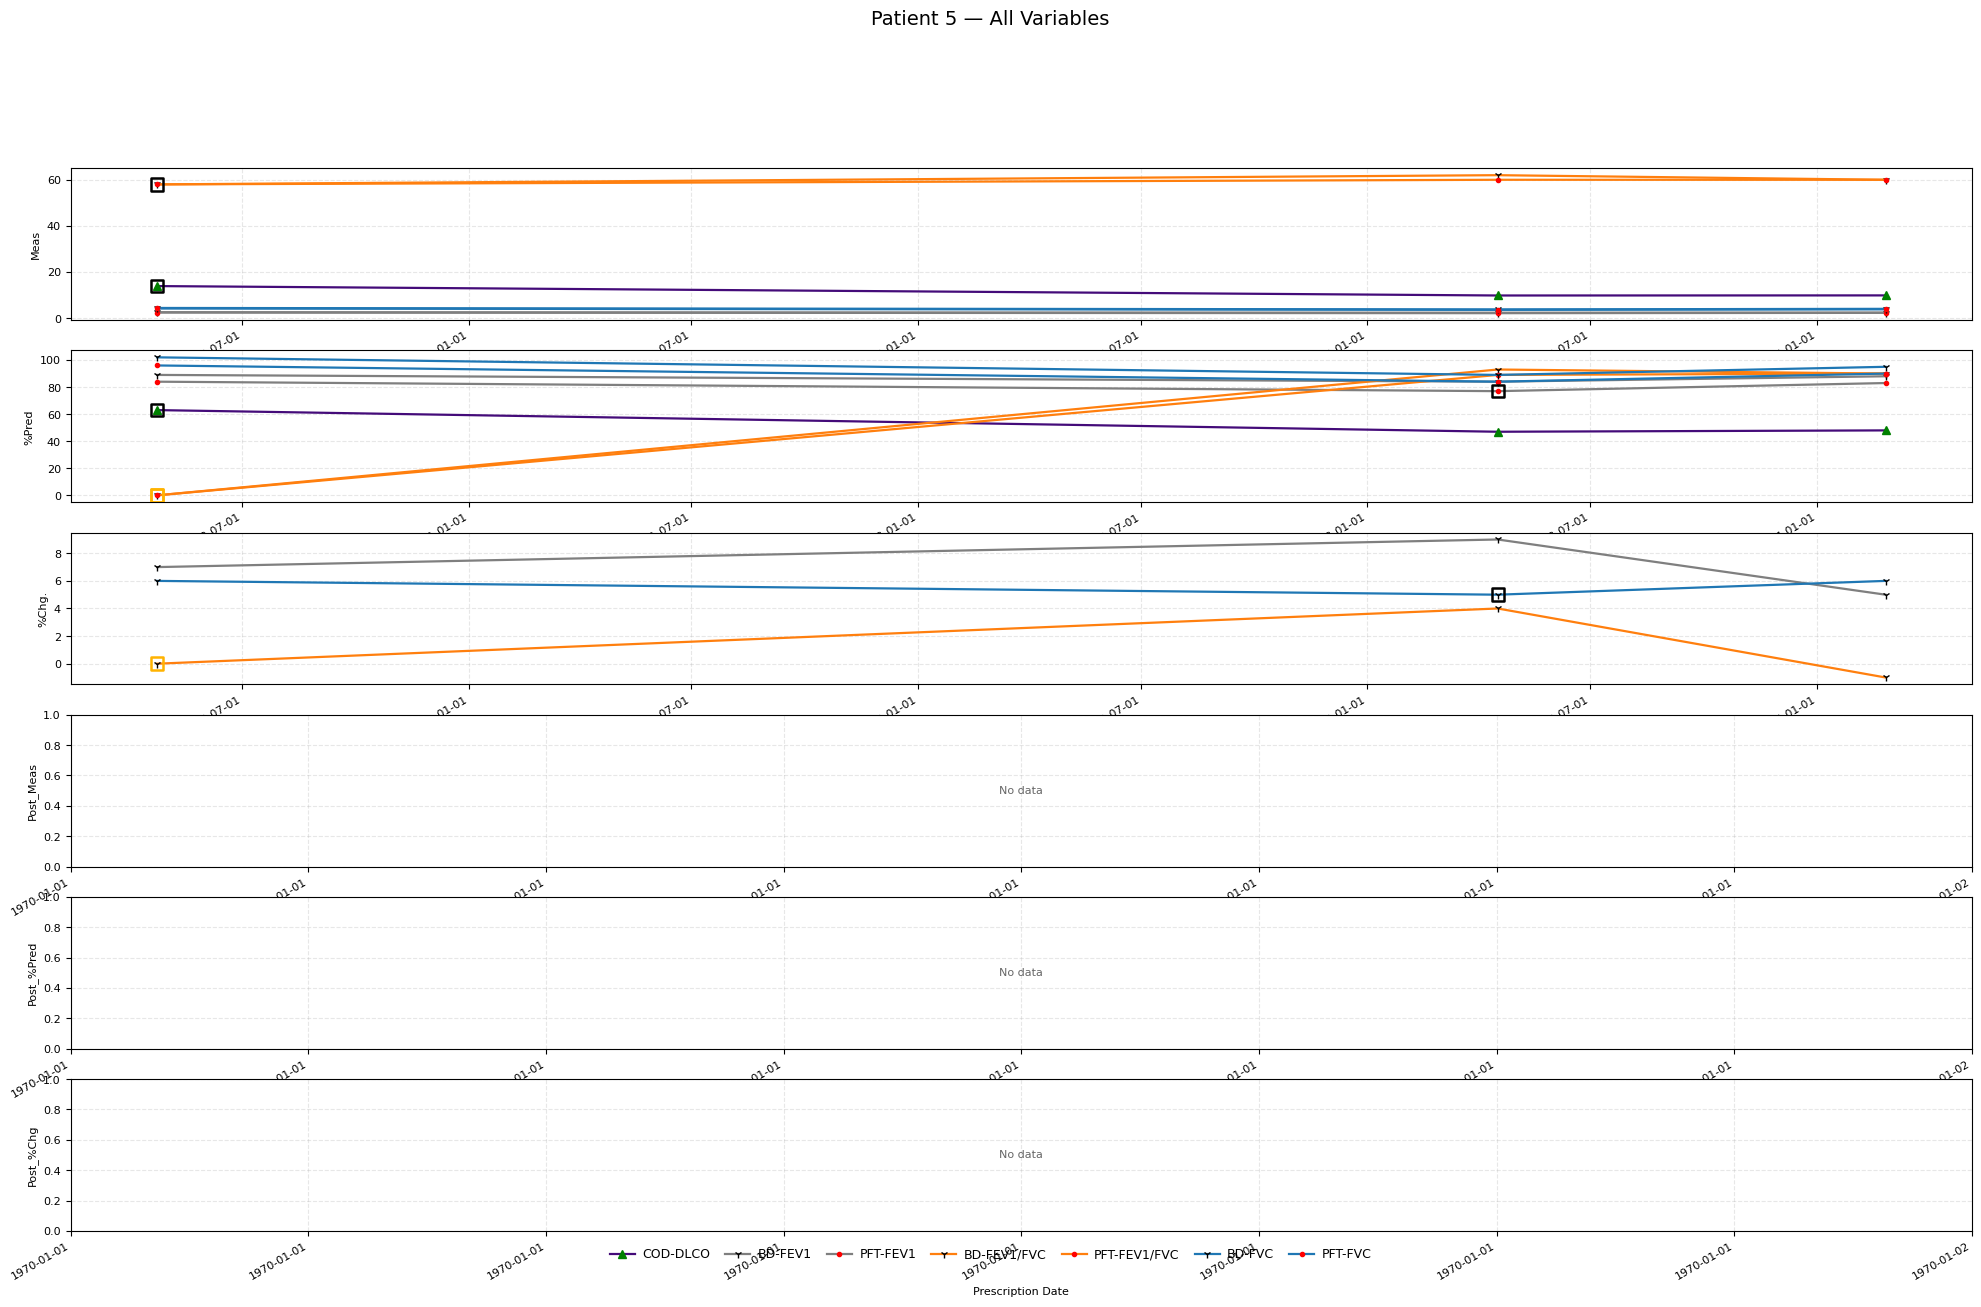

In [73]:
# ---- constants / basic prep ----
DATE_COL  = "Prescription Date"
VALUE_COL = "Result Numerical Value"
VAR_COL   = "Variable"
MEAS_COL  = "Measurement"

dfx = dfx.copy()
dfx[DATE_COL] = pd.to_datetime(dfx[DATE_COL], errors="coerce")
dfx = dfx.sort_values(DATE_COL)

if plot_variable_order is None:
    plot_variable_order = ["Meas", "%Pred", "%Chg.", "Post_Meas", "Post_%Pred", "Post_%Chg"]
if wanted_measure_indexes is None:
    wanted_measure_indexes = sorted(dfx[MEAS_COL].dropna().unique().tolist())
if measure_index_colors is None:
    # base = ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
    # '#9467bd'
    base = ["#440B79", '#7f7f7f', '#ff7f0e', '#1f77b4', '#aec7e8',  '#ffbb78', '#2ca02c', '#98df8a', '#d62728','#ff9896',  
            '#c5b0d5','#8c564b', '#c49c94', '#e377c2', '#f7b6d2','#c7c7c7', '#bcbd22', '#dbdb8d', '#17becf', '#9edae5']
    measure_index_colors = {mi: c for mi, c in zip(wanted_measure_indexes, itertools.cycle(base))}
# Define marker mapping per Test
MARKERS_BY_TEST = {"PFT": ".", "BD": "1", "COD": "^", None: "|"}
MARKER_COLORS_BY_TEST = {"PFT": "red", "BD": "black", "COD": "green", None: "blue"}

# anomaly colors (distinct from typical Matplotlib defaults)
ANOM_COLORS = {
    "Missing": "#FFB300",  # amber
    "Range":   "#8B0000",  # dark red
    "MAD":     "#000000",  # black
    "Jump":    "#00BFA6",  # teal
}
have_anom_cols = all(
    col in dfx.columns
    for col in ["Anomaly_Missing", "Anomaly_Range", "Outlier_MAD", "Outlier_Jump"]
)

# ---- figure & axes ----
nrows = len(plot_variable_order)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=((16*2.3*nrows) / 9, 2.3*nrows), sharex=False)
if nrows == 1:
    axes = [axes]

handles_all, labels_all = [], []

# ---- plotting per variable ----
for ax, var in zip(axes, plot_variable_order):
    dft_var = dfx[dfx[VAR_COL] == var]
    ax.set_ylabel(var)
    ax.grid(True, linestyle="--", alpha=0.3)

    any_line = False
    for mi in wanted_measure_indexes:
        dft_sub  = dft_var[dft_var[MEAS_COL] == mi]

        # group by Test so each subgroup has its own marker
        for test_val, dft in dft_sub.groupby("Test"):
            h, = ax.plot(
                dft[DATE_COL],
                dft[VALUE_COL],
                marker=MARKERS_BY_TEST.get(test_val, "|"),
                markerfacecolor=MARKER_COLORS_BY_TEST.get(test_val, "blue"),
                markeredgecolor=MARKER_COLORS_BY_TEST.get(test_val, "blue"),
                linewidth=linewidth,
                color=measure_index_colors.get(mi, "black"),
                label=f"{test_val}-{mi}", zorder=2,
            )
            any_line = True
            if not any(lbl.get_label() == f"{test_val}-{mi}" for lbl in handles_all):
                handles_all.append(h)
                labels_all.append(f"{test_val}-{mi}")

            # anomaly overlays (squares) — only if anomaly cols exist
            if plot_anomaly and have_anom_cols:
                anom_specs = [
                    ("MAD",     "Outlier_MAD"),
                    ("Jump",    "Outlier_Jump"),
                    ("Range",   "Anomaly_Range"),
                    ("Missing", "Anomaly_Missing"),
                ]
                for key, col in anom_specs:
                    if col in dft.columns and dft[col].any():
                        bad = dft[dft[col]]
                        ax.scatter(
                            bad[DATE_COL], bad[VALUE_COL],
                            s=80, marker="s",
                            facecolors="none", edgecolors=ANOM_COLORS[key],
                            linewidths=1.8, zorder=4
                        )

    if not any_line:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, alpha=0.6)

    # x-axis as full date per subplot
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha("right")

# x-label only on bottom subplot
axes[-1].set_xlabel("Prescription Date")

# title (with optional suffix)
fig.suptitle(
    f"Patient {patient_id} — All Variables{(' — ' + title_suffix) if title_suffix else ''}",
    y=0.995, fontsize=14
)

# -------- LEGENDS (measurement row, then one anomaly per line) --------
# 1) Measurement legend: single row
if handles_all:
    fig.legend(
        handles_all, labels_all,
        loc="lower center", bbox_to_anchor=(0.5, 0.08),
        ncol=len(labels_all), fontsize=9, frameon=False,
        handlelength=2.0, handletextpad=0.6, columnspacing=1.2
    )

# 2) One line per anomaly (stacked)

# anom_specs = [
#     ("Missing Value: Value is zero.", ANOM_COLORS["Missing"]),
#     ("Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; FEV1/FVC 0.2-1.2; %Pred 0-200.", ANOM_COLORS["Range"]),
#     ("MAD: |robust_z| > z_thresh (3.5)", ANOM_COLORS["MAD"]),
#     ("Jump: Δ/month > thresholds (FEV1 0.30, FVC 0.40, DLCO 3.0, FEV1/FVC 0.08, DLCO/VA 0.60).", ANOM_COLORS["Jump"]),
# ]
anom_specs = [
    ("Missing Value: Value is zero.", ANOM_COLORS["Missing"]),
    ("Out of Valid Range: FEV1 & FVC (Meas/Post_Meas) 0.2-10.0; DLCO 0.3-50; "
    "FEV1/FVC 20-120; %Pred 0-200.", ANOM_COLORS["Range"]),
    ("MAD: |robust_z| > z_thresh (3.5)", ANOM_COLORS["MAD"]),
    ("Jump (Δ/month) — Meas: FEV1 0.3, FVC 0.4, DLCO 3.0, FEV1/FVC 8%, DLCO/VA 0.6.\n"
    "Jump (Δ/month) — %Pred: FEV1 8%, FVC 8%, DLCO 8%, FEV1/FVC 8%, DLCO/VA 8%.\n"
    "Jump (Δ/month) — %Chg.: FEV1 7%, FVC 4%, DLCO 0.3%, FEV1/FVC 4%, DLCO/VA 0.6%.",
    ANOM_COLORS["Jump"]),
]

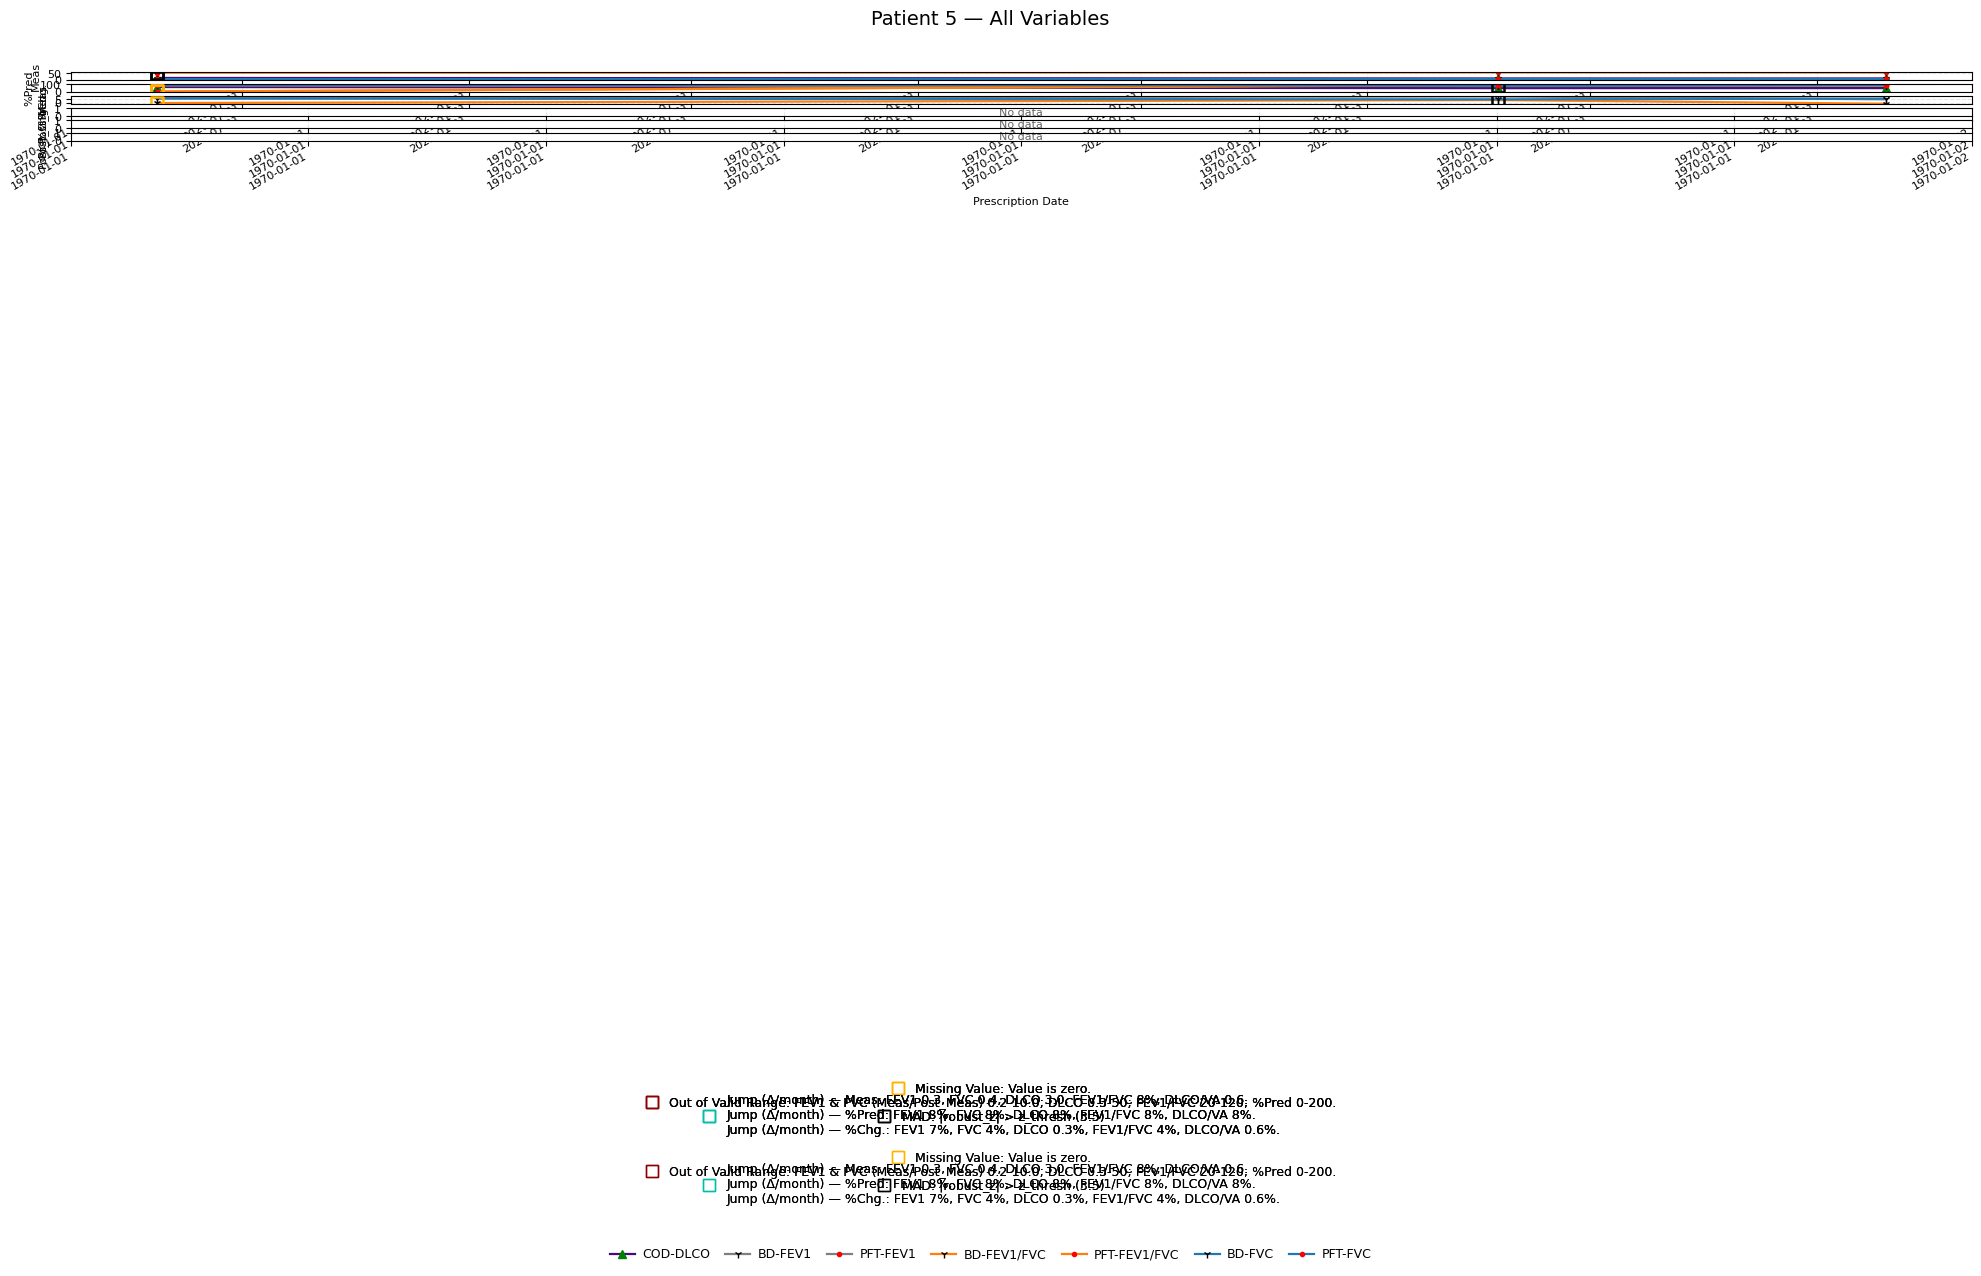

In [84]:
y0, dy = 0.2, 0.01   # starting y and spacing between lines
for i, (lab, col) in enumerate(anom_specs):
    h = Line2D([0],[0], marker='s', linestyle='None', markersize=8,
                markerfacecolor='none', markeredgecolor=col, label=lab)
    fig.legend(
        [h], [lab],
        loc="lower center", bbox_to_anchor=(0.5, y0 - i*dy),
        ncol=1, fontsize=9, frameon=False, handlelength=1.2
    )

# room for 1 (measurements) + 4 (anomalies) lines
# fig.subplots_adjust(bottom=0.16, top=0.95, hspace=0.5)
fig.subplots_adjust(bottom=0.9, top=0.95, hspace=0.5)
fig

In [ ]:
def plot_variable_statistics(df_path: str | Path = INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv",
                             output_dir: Path = Path(FIGURES_DIR / "Variant_statistics")
                             ) -> None:
    
    plt.rcParams.update({
    "font.size": 8,       # base font size
    "axes.titlesize": 10,  # title
    "axes.labelsize": 8,  # x and y labels
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
    })
    # plt.rcParams.update(plt.rcParamsDefault)

    df = pd.read_csv(df_path)
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output directory created at: {output_dir}")
    
    df["Prescription Date"] = pd.to_datetime(df["Prescription Date"], format="%Y%m%d", errors="coerce")
    df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

    for test in df["Test"].unique():
        for meas in df["Measurement"].unique():
            for var in ['Meas', '%Pred', '%Chg.', 'Post_Meas', 'Post_%Chg', 'Post_%Pred']: #df["Variable"].unique():
                df_filtered = df[(df["Test"] == test) & (df["Measurement"] == meas) & (df["Variable"] == var)]
                if df_filtered.empty:
                    continue
                # Replace problematic characters (/ \ spaces) with underscore
                safe_test  = re.sub(r"[\\/]", "_", str(test))
                safe_meas = re.sub(r"[\\/]", "_", str(meas))
                safe_var  = re.sub(r"[\\/]", "_", str(var))
                print(f"Test: {test} , Measurement: {meas}, Variable: {var} | "
                      f"Unique: {df_filtered['Patient Number'].nunique()} | "
                      f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
                      f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
                      f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}")
                # plot
                # plt.figure(figsize=(10, 6))
                plt.figure(figsize=(4.5, 2.7))
                plt.hist(df_filtered['Result Numerical Value'].dropna(), bins=30, color='skyblue', alpha=0.7)
                plt.xlabel('Result Numerical Value')
                plt.ylabel('Frequency')
                plt.title(
                    f"Distribution of '{var}' for '{test}' - '{meas}'\n"
                    f"Unique Patients: {df_filtered['Patient Number'].nunique()}\n"
                    f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
                    f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
                    f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}"
                )
                plt.tight_layout()
                plt.savefig(Path(output_dir) / f"{safe_var}_{safe_test}_{safe_meas}_distribution.png")
                plt.close()

In [ ]:
plot_variable_statistics

In [ ]:
def plot_variable_statistics(df_path: str | Path = INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv",
                             output_dir: Path = Path(FIGURES_DIR / "Variant_statistics")
                             ) -> None:
    
    plt.rcParams.update({
    "font.size": 8,       # base font size
    "axes.titlesize": 10,  # title
    "axes.labelsize": 8,  # x and y labels
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
    })
    # plt.rcParams.update(plt.rcParamsDefault)

    df = pd.read_csv(df_path)
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output directory created at: {output_dir}")
    
    df["Prescription Date"] = pd.to_datetime(df["Prescription Date"], format="%Y%m%d", errors="coerce")
    df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

    for test in df["Test"].unique():
        for meas in df["Measurement"].unique():
            for var in ['Meas', '%Pred', '%Chg.', 'Post_Meas', 'Post_%Chg', 'Post_%Pred']: #df["Variable"].unique():
                df_filtered = df[(df["Test"] == test) & (df["Measurement"] == meas) & (df["Variable"] == var)]
                if df_filtered.empty:
                    continue
                # Replace problematic characters (/ \ spaces) with underscore
                safe_test  = re.sub(r"[\\/]", "_", str(test))
                safe_meas = re.sub(r"[\\/]", "_", str(meas))
                safe_var  = re.sub(r"[\\/]", "_", str(var))
                print(f"Test: {test} , Measurement: {meas}, Variable: {var} | "
                      f"Unique: {df_filtered['Patient Number'].nunique()} | "
                      f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
                      f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
                      f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}")
                # plot
                # plt.figure(figsize=(10, 6))
                plt.figure(figsize=(4.5, 2.7))
                plt.hist(df_filtered['Result Numerical Value'].dropna(), bins=30, color='skyblue', alpha=0.7)
                plt.xlabel('Result Numerical Value')
                plt.ylabel('Frequency')
                plt.title(
                    f"Distribution of '{var}' for '{test}' - '{meas}'\n"
                    f"Unique Patients: {df_filtered['Patient Number'].nunique()}\n"
                    f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
                    f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
                    f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}"
                )
                plt.tight_layout()
                plt.savefig(Path(output_dir) / f"{safe_var}_{safe_test}_{safe_meas}_distribution.png")
                plt.close()

plot_variable_statistics()

In [ ]:
from pathlib import Path
import re
from typing import Any, Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_variable_statistics(
    df_path: str | Path,
    output_dir: Path,
    *,
    log_mode: str = "none",          # "none" | "logy" | "logx" | "logdata"
    bins: int = 30
) -> None:
    """
    Make per-(Test, Measurement, Variable) histograms with optional log scaling.

    log_mode:
      - "none"    : normal histogram.
      - "logy"    : log scale on y-axis (counts). Works with any values.
      - "logx"    : log scale on x-axis (values). Requires values > 0.
      - "logdata" : histogram of log10(values). Requires values > 0.

    Advantages:
      • logy: reveals rare tail counts without losing the bulk near zero.
      • logx: spreads small values, compresses long right tail (orders of magnitude).
      • logdata: if data are log-normal, distribution becomes closer to normal.
    """
    # fonts (small, consistent)
    plt.rcParams.update({
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8
    })

    df = pd.read_csv(df_path)
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output directory created at: {output_dir}")

    df["Prescription Date"] = pd.to_datetime(df["Prescription Date"], format="%Y%m%d", errors="coerce")
    df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

    # fixed variable order (adjust as needed)
    wanted_vars = ['Meas', '%Pred', '%Chg.', 'Post_Meas', 'Post_%Chg', 'Post_%Pred']

    for test in df["Test"].dropna().unique():
        for meas in df["Measurement"].dropna().unique():
            for var in wanted_vars:
                df_filtered = df[(df["Test"] == test) & (df["Measurement"] == meas) & (df["Variable"] == var)]
                if df_filtered.empty:
                    continue

                # Clean file-safe parts
                safe = lambda s: re.sub(r"[\\/]", "_", str(s))
                safe_test, safe_meas, safe_var = safe(test), safe(meas), safe(var)

                vals = df_filtered['Result Numerical Value'].dropna()
                if vals.empty:
                    continue

                # Stats (on original scale)
                n_pat = df_filtered['Patient Number'].nunique()
                vmin, vmax, vmean = vals.min(), vals.max(), vals.mean()

                # ---- pick plot mode ----
                title_suffix = ""
                zeros_or_neg = int((vals <= 0).sum())

                if log_mode == "logy":
                    # log counts
                    plt.figure(figsize=(4.5, 2.7))
                    plt.hist(vals, bins=bins, alpha=0.7, log=True)
                    plt.ylabel('Frequency (log scale)')
                    title_suffix = " [log-y]"

                elif log_mode == "logx":
                    # log x-axis → need positive values
                    pos = vals[vals > 0]
                    if pos.empty:
                        print(f"[skip logx] {test}-{meas}-{var}: no positive values.")
                        continue
                    # log-spaced bins
                    lo, hi = pos.min(), pos.max()
                    if lo == hi:   # avoid identical bin edges
                        lo *= 0.9
                        hi *= 1.1
                    log_bins = np.logspace(np.log10(lo), np.log10(hi), bins)
                    plt.figure(figsize=(4.5, 2.7))
                    plt.hist(pos, bins=log_bins, alpha=0.7)
                    plt.xscale('log')
                    plt.xlabel('Result Numerical Value (log scale)')
                    if zeros_or_neg:
                        title_suffix = f" [log-x | excl ≤0: {zeros_or_neg}]"
                    else:
                        title_suffix = " [log-x]"

                elif log_mode == "logdata":
                    # histogram of log10(values) → need positive values
                    pos = vals[vals > 0]
                    if pos.empty:
                        print(f"[skip logdata] {test}-{meas}-{var}: no positive values.")
                        continue
                    plt.figure(figsize=(4.5, 2.7))
                    plt.hist(np.log10(pos), bins=bins, alpha=0.7)
                    plt.xlabel('log10(Result Numerical Value)')
                    title_suffix = " [log10(data)]"

                else:  # "none"
                    plt.figure(figsize=(4.5, 2.7))
                    plt.hist(vals, bins=bins, alpha=0.7)

                # Common labels
                if log_mode != "logx":  # logx already set a custom x label
                    plt.xlabel('Result Numerical Value')
                plt.ylabel('Frequency')
                plt.title(
                    f"Distribution of '{var}' for '{test}' - '{meas}'{title_suffix}\n"
                    f"Unique Patients: {n_pat}\n"
                    f"Min: {vmin:.2f}, Max: {vmax:.2f}, Mean: {vmean:.2f}"
                )

                plt.tight_layout()

                # Save with mode tag
                mode_tag = {"none":"lin", "logy":"logy", "logx":"logx", "logdata":"logdata"}[log_mode]
                out_name = f"{safe_var}_{safe_test}_{safe_meas}_distribution_{mode_tag}.png"
                plt.savefig(Path(output_dir) / out_name, dpi=300)
                plt.close()

plot_variable_statistics(INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv",
                         FIGURES_DIR / "Variant_statistics", log_mode="logdata")


C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_73360\3934138165.py:39: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


Output directory created at: D:\Research\Project_COPD\COPD\reports\figures\Variant_statistics


In [93]:
import numpy as np
np.log10(100)

2.0

C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_73360\3955514607.py:6: DtypeWarning: Columns (2,4,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


Output directory created at: D:\Research\Project_COPD\COPD\reports\figures\Variant_statistics
Test: BD , Measurement: FEV1/FVC, Variable: %Pred | Unique: 2433 | Min: 0.00, Max: 140.00, Mean: 5.76


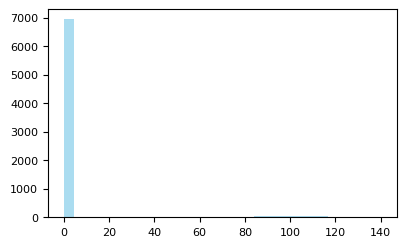

In [97]:
import pandas as pd

df_path = Path(INTERIM_DATA_DIR / "ALL_PRESCRIPTION_DATA_FILTERED.csv")
output_dir = Path(FIGURES_DIR / "Variant_statistics")

df = pd.read_csv(df_path)
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory created at: {output_dir}")

df["Prescription Date"] = pd.to_datetime(df["Prescription Date"], format="%Y%m%d", errors="coerce")
df["Result Numerical Value"] = pd.to_numeric(df["Result Numerical Value"], errors="coerce")

# for test in df["Test"].unique():
#     for meas in df["Measurement"].unique():
#         for var in ['Meas', '%Pred', '%Chg.', 'Post_Meas', 'Post_%Chg', 'Post_%Pred']: #df["Variable"].unique():
test = "BD"
meas = "FEV1/FVC"
var = "%Pred"
df_filtered = df[(df["Test"] == test) & (df["Measurement"] == meas) & (df["Variable"] == var)]

print(f"Test: {test} , Measurement: {meas}, Variable: {var} | "
        f"Unique: {df_filtered['Patient Number'].nunique()} | "
        f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
        f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
        f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}")
# plot
# plt.figure(figsize=(10, 6))
plt.figure(figsize=(4.5, 2.7))
h = plt.hist(df_filtered['Result Numerical Value'].dropna(), bins=30, color='skyblue', alpha=0.7)
# plt.xlabel('Result Numerical Value')
# plt.ylabel('Frequency')
# plt.title(
#     f"Distribution of '{var}' for '{test}' - '{meas}'\n"
#     f"Unique Patients: {df_filtered['Patient Number'].nunique()}\n"
#     f"Min: {df_filtered['Result Numerical Value'].min():.2f}, "
#     f"Max: {df_filtered['Result Numerical Value'].max():.2f}, "
#     f"Mean: {df_filtered['Result Numerical Value'].mean():.2f}"
# )
# plt.tight_layout()
# plt.savefig(Path(output_dir) / f"{safe_var}_{safe_test}_{safe_meas}_distribution.png")
# plt.close()

In [ ]:
h[1]  # This will show the histogram bin counts
# what is h[0] and h[1] ?
h[0]  # This will show the histogram bin edges
h[1]  # This will show the histogram bin counts
# explain with an example
# For example, if h[0] = [0, 1, 2, 3, 4, 5] and h[1] = [10, 20, 30, 40, 50], it means:
# - The bins are [0, 1), [1, 2), [2, 3), [3, 4), [4, 5)
# - The counts for these bins are 10, 20, 30, 40, 50 respectively

array([  0.        ,   4.66666667,   9.33333333,  14.        ,
        18.66666667,  23.33333333,  28.        ,  32.66666667,
        37.33333333,  42.        ,  46.66666667,  51.33333333,
        56.        ,  60.66666667,  65.33333333,  70.        ,
        74.66666667,  79.33333333,  84.        ,  88.66666667,
        93.33333333,  98.        , 102.66666667, 107.33333333,
       112.        , 116.66666667, 121.33333333, 126.        ,
       130.66666667, 135.33333333, 140.        ])

In [112]:
h[0]

array([6.94e+03, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       2.00e+00, 3.00e+00, 4.00e+00, 9.00e+00, 5.00e+00, 8.00e+00,
       1.10e+01, 1.40e+01, 1.00e+01, 1.90e+01, 2.20e+01, 1.70e+01,
       3.30e+01, 4.90e+01, 4.20e+01, 4.20e+01, 5.20e+01, 2.90e+01,
       3.80e+01, 2.20e+01, 1.70e+01, 5.00e+00, 4.00e+00, 2.00e+00])

In [116]:
# 6.94e+03 to normal format without 10 to the power
normal_format = [f"{count:.2f}" for count in h[0]]
# Select specific elements by index (as a list, not tuple)
count = [normal_format[i] for i in [0, 1, 6, 7, 8, 9, -1]]

In [119]:
print(count)
logy = [f"{np.log10(float(c)):.2f}" for c in count]
print(logy)

['6940.00', '0.00', '2.00', '3.00', '4.00', '9.00', '2.00']
['3.84', '-inf', '0.30', '0.48', '0.60', '0.95', '0.30']


C:\Users\Shayahn-DKE\AppData\Local\Temp\ipykernel_73360\595938550.py:2: RuntimeWarning: divide by zero encountered in log10
  logy = [f"{np.log10(float(c)):.2f}" for c in count]


In [109]:
h[0]
# convert h[0] to a more readable format
bin_edges = h[0]
bin_edges = [f"[{bin_edges[i]}, {bin_edges[i + 1]})" for i in range(len(bin_edges) - 1)]

In [110]:
# convert h[1] to a more readable format
bin_counts = h[1]
bin_counts = [f"{bin_counts[i]}" for i in range(len(bin_counts))]


In [ ]:
# h[1]

['0.0',
 '4.666666666666667',
 '9.333333333333334',
 '14.0',
 '18.666666666666668',
 '23.333333333333336',
 '28.0',
 '32.66666666666667',
 '37.333333333333336',
 '42.0',
 '46.66666666666667',
 '51.333333333333336',
 '56.0',
 '60.66666666666667',
 '65.33333333333334',
 '70.0',
 '74.66666666666667',
 '79.33333333333334',
 '84.0',
 '88.66666666666667',
 '93.33333333333334',
 '98.0',
 '102.66666666666667',
 '107.33333333333334',
 '112.0',
 '116.66666666666667',
 '121.33333333333334',
 '126.00000000000001',
 '130.66666666666669',
 '135.33333333333334',
 '140.0']